# **Spatial Data Operations and Concepts**
https://spatialdata.scverse.org/en/stable/tutorials/notebooks/notebooks/examples/intro.html#key-terms-and-data-model
## Key terms and data model
SpatialData objects are representations of spatial omics data, which are manipulated with the SpatialData framework. On-disk, these are stored as .zarr stores, which are essentially folders containing data and metadata in a structured, but flexible format.

We can think of a SpatialData object as a container for various Elements. An Element is either a SpatialElement (Images, Labels, Points, Shapes) or a Table. Here is a brief description:

Images: H&E, staining images

Labels: pixel-level segmentation

Points: transcripts locations with gene information, landmarks points

Shapes: cell/nucleus boundaries, subcellular structures, anatomical annotations, regions of interest (ROIs)

Tables: sparse/dense matrices annotating the the SpatialElements or storing arbitrary (non-spatial) metadata. They do not contain spatial coordinates.

We can categorize the SpatialElements into two broad types:

Rasters: Data made up of pixels: including Images and Labels

Vectors: Data made up of points and lines. Polygons are also vectors, since they are a simply a list of connected points. Points and Shapes are elements of this type.

We will see examples of manipulating these below and leave advanced usage in other tutorials.

In [2]:
import spatialdata as sd
import spatialdata_plot  # noqa: F401
from pyhere import here

In [ ]:
here("data","processed","concatenated_sdata_processed")
/Users/jmakings/Documents/Projects/VisiumHD/data/processed/concatenated_sdata_processed.zarr

PosixPath('/Users/jmakings/Documents/Projects/visiumhd/data/processed/concatenated_sdata_processed')

In [15]:
sdata = sd.read_zarr(here("data","processed","concatenated_sdata_processed.zarr"))

version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/jmakings/miniforge3/envs/visiumhd/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04


In [16]:
sdata

SpatialData object, with associated Zarr store: /Users/jmakings/Documents/Projects/visiumhd/data/processed/concatenated_sdata_processed.zarr
├── Images
│     ├── 'Colon_Cancer_P1_hires_tissue_image': DataArray[cyx] (3, 4961, 6000)
│     ├── 'Colon_Cancer_P2_hires_tissue_image': DataArray[cyx] (3, 3886, 6000)
│     ├── 'Colon_Normal_P3_hires_tissue_image': DataArray[cyx] (3, 3168, 6000)
│     └── 'Colon_Normal_P5_hires_tissue_image': DataArray[cyx] (3, 4153, 6000)
├── Shapes
│     ├── 'Colon_Cancer_P1_cell_boundaries': GeoDataFrame shape: (217952, 2) (2D shapes)
│     ├── 'Colon_Cancer_P2_cell_boundaries': GeoDataFrame shape: (220404, 2) (2D shapes)
│     ├── 'Colon_Normal_P3_cell_boundaries': GeoDataFrame shape: (75526, 2) (2D shapes)
│     └── 'Colon_Normal_P5_cell_boundaries': GeoDataFrame shape: (138374, 2) (2D shapes)
└── Tables
      └── 'segmentation_counts': AnnData (612699, 17962)
with coordinate systems:
    ▸ 'downscale_to_hires', with elements:
        Colon_Cancer_P1_hires_

In [17]:
sdata["Colon_Cancer_P1_hires_tissue_image"]

<xarray.DataArray 'image' (c: 3, y: 4961, x: 6000)> Size: 89MB
dask.array<from-zarr, shape=(3, 4961, 6000), dtype=uint8, chunksize=(3, 4961, 6000), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) int64 24B 0 1 2
  * y        (y) float64 40kB 0.5 1.5 2.5 3.5 ... 4.958e+03 4.96e+03 4.96e+03
  * x        (x) float64 48kB 0.5 1.5 2.5 3.5 ... 5.998e+03 5.998e+03 6e+03
Attributes:
    transform:  {'downscale_to_hires': Identity }

In [18]:
sdata["Colon_Cancer_P1_cell_boundaries"]

,cell_id,geometry
Colon_Cancer_P1_cellid_000000002-1,Colon_Cancer_P1_cellid_000000002-1,"POLYGON ((3834.5 13430.8, 3834.5 13423.5, 3819..."
Colon_Cancer_P1_cellid_000000003-1,Colon_Cancer_P1_cellid_000000003-1,"POLYGON ((1796.3 14237.6, 1796.4 14230.3, 1781..."
Colon_Cancer_P1_cellid_000000006-1,Colon_Cancer_P1_cellid_000000006-1,"POLYGON ((2190.8 14233.9, 2190.8 14226.6, 2176..."
Colon_Cancer_P1_cellid_000000008-1,Colon_Cancer_P1_cellid_000000008-1,"POLYGON ((2749.5 13851.9, 2749.5 13844.6, 2734..."
Colon_Cancer_P1_cellid_000000009-1,Colon_Cancer_P1_cellid_000000009-1,"POLYGON ((1695.6 13279.6, 1695.7 13272.3, 1681..."
...,...,...
Colon_Cancer_P1_cellid_000257684-1,Colon_Cancer_P1_cellid_000257684-1,"POLYGON ((24155 35536.2, 24155.2 35514.3, 2416..."
Colon_Cancer_P1_cellid_000257691-1,Colon_Cancer_P1_cellid_000257691-1,"POLYGON ((23383.9 35974.7, 23384.1 35952.8, 23..."
Colon_Cancer_P1_cellid_000257692-1,Colon_Cancer_P1_cellid_000257692-1,"POLYGON ((23671 36525.3, 23671 36518, 23663.7 ..."
Colon_Cancer_P1_cellid_000257698-1,Colon_Cancer_P1_cellid_000257698-1,"POLYGON ((23898.9 35585, 23899.1 35563, 23906...."


In [19]:
sdata["segmentation_counts"]

AnnData object with n_obs × n_vars = 612699 × 17962
    obs: 'sample', 'cell_id', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'clusters', 'orig_clusters', 'grouped_clusters'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'clusters', 'clusters_colors', 'dendrogram_clusters', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'filtered_counts'
    obsp: 'connectivities', 'distances'

/Users/jmakings/miniforge3/envs/visiumhd/lib/python3.10/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `Colon_Cancer_P1_cell_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/jmakings/miniforge3/envs/visiumhd/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `segmentation_counts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


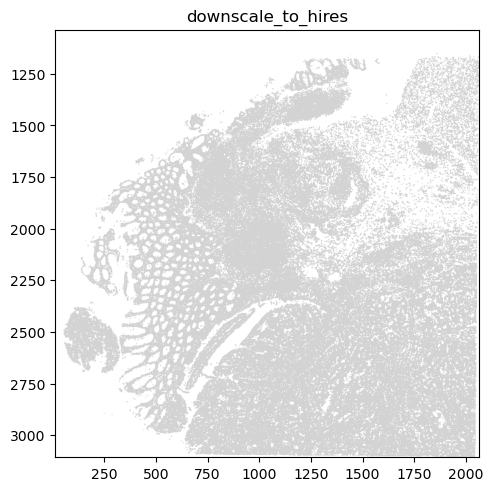

In [20]:
sdata.pl.render_shapes("Colon_Cancer_P1_cell_boundaries", color="Hal").pl.show()

/Users/jmakings/miniforge3/envs/visiumhd/lib/python3.10/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `Colon_Cancer_P2_cell_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/jmakings/miniforge3/envs/visiumhd/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `segmentation_counts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


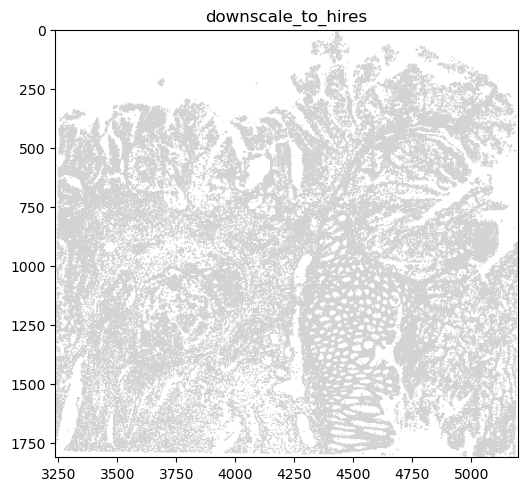

In [21]:
sdata.pl.render_shapes("Colon_Cancer_P2_cell_boundaries", color="Hal").pl.show()